# Chapter 7 — Matrix Applications

## Learning Objectives

This notebook covers covariance matrices, correlation matrices, geometric transformations, and image-like feature detection.

## Theoretical Explanation

Matrix multiplication organizes many dot products at once. A covariance matrix is created from a mean-centered data matrix using `X.T @ X / (n-1)`. A transformation matrix can rotate, scale, or shear points. Image filtering uses local element-wise multiplication and summation, extending dot-product logic into two dimensions.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import norm, matrix_rank

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Covariance and Correlation Matrix

Covariance matrix:
 [[ 0.817  0.666 -0.049  0.044]
 [ 0.666  0.578 -0.041  0.033]
 [-0.049 -0.041  1.122  0.019]
 [ 0.044  0.033  0.019  0.995]]

Correlation matrix:
 [[ 1.     0.968 -0.052  0.048]
 [ 0.968  1.    -0.051  0.043]
 [-0.052 -0.051  1.     0.018]
 [ 0.048  0.043  0.018  1.   ]]


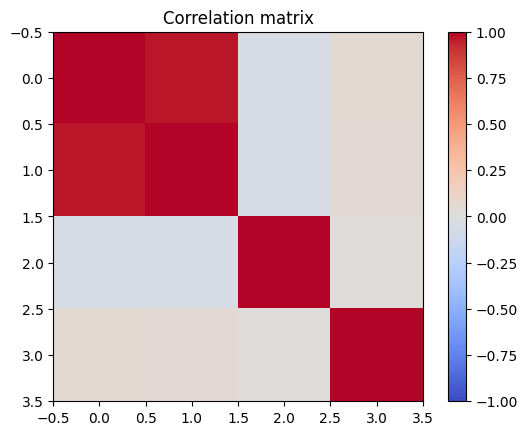

In [2]:
rng = np.random.RandomState(RANDOM_STATE)
X = rng.randn(200,4)
X[:,1] = X[:,0]*0.8 + rng.randn(200)*0.2
Xm = X - X.mean(axis=0)
cov = Xm.T @ Xm / (X.shape[0]-1)
std_inv = np.diag(1/np.sqrt(np.diag(cov)))
corr = std_inv @ cov @ std_inv
print('Covariance matrix:\n', np.round(cov, 3))
print('\nCorrelation matrix:\n', np.round(corr, 3))
plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(); plt.title('Correlation matrix')
plt.show()

### Output Interpretation

The correlation matrix normalizes covariance values to the range near -1 to 1. The strong correlation between the first two variables appears clearly.

## 2. Geometric Transformation

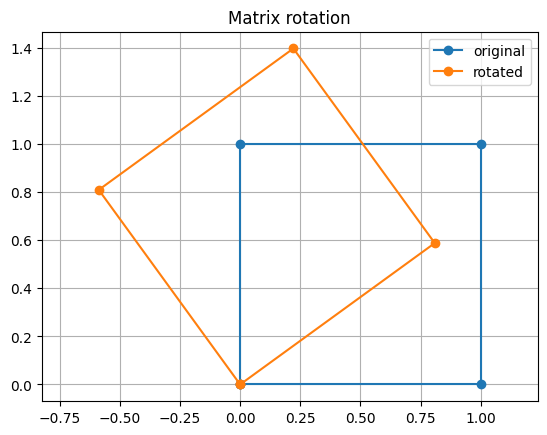

In [3]:
theta = np.pi/5
T = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
points = np.array([[0,1,1,0,0], [0,0,1,1,0]])
rotated = T @ points
plt.plot(points[0], points[1], 'o-', label='original')
plt.plot(rotated[0], rotated[1], 'o-', label='rotated')
plt.axis('equal'); plt.grid(True); plt.legend(); plt.title('Matrix rotation')
plt.show()

### Output Interpretation

The rotation matrix changes the orientation of the square while preserving distances. This is an example of matrix-vector multiplication as geometry.

## 3. Simple Image Smoothing

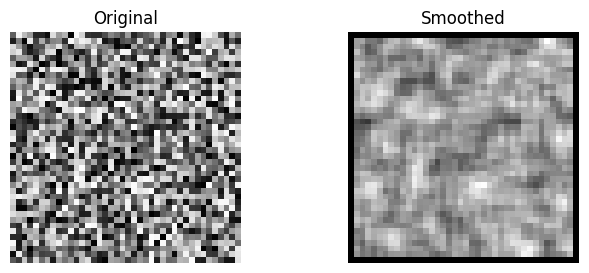

In [4]:
image = np.random.rand(40,40)
kernel = np.ones((3,3))/9
out = np.zeros_like(image)
for i in range(1,39):
    for j in range(1,39):
        out[i,j] = np.sum(image[i-1:i+2,j-1:j+2]*kernel)
fig, ax = plt.subplots(1,2,figsize=(8,3))
ax[0].imshow(image,cmap='gray'); ax[0].set_title('Original')
ax[1].imshow(out,cmap='gray'); ax[1].set_title('Smoothed')
for a in ax: a.axis('off')
plt.show()

### Output Interpretation

The kernel averages local neighborhoods, reducing high-frequency noise. This is the matrix version of filtering through local weighted sums.

## Extended Study Notes

The central learning objective is not only to run code, but to connect the numerical result back to the linear algebra idea. In applied data science, vectors and matrices are not abstract objects only; they are the representation layer for observations, features, images, time series, model parameters, transformations, and decompositions.

A professional workflow should always include sanity checks. For example, reconstructed matrices should be compared with the original matrix, orthogonal matrices should be checked with `Q.T @ Q`, inverse computations should be checked against the identity matrix, and least-squares predictions should be inspected through residuals. These checks make the notebook academically stronger and reduce the risk of blindly trusting a black-box function.

## Chapter Summary

This notebook reproduces the core concept of the chapter using original/adapted Python examples. The code is intentionally compact but runnable, and the surrounding explanation focuses on conceptual understanding, interpretation, and practical relevance for data science.

## Key Takeaways

- Linear algebra concepts become clearer when formulas, geometry, and code are studied together.
- NumPy provides efficient implementations, but understanding the underlying math helps prevent misuse.
- Shape, rank, orientation, and numerical stability are recurring concerns in applied linear algebra.
- Every output should be interpreted as evidence of a mathematical property, not merely as a printed result.